# GPR Index — Probabilistic Estimation Engine (Artefact 1)

```
# Student Name: TODO(student): Your Full Name
# Student FAN: WUTT0019
# File: GPR_Index_Analysis.ipynb
# Date: TODO(student): DD-MM-YYYY
# Description: Frequentist vs Bayesian parameter estimation on the GPR Index.
# Usage: open in Jupyter and Run All; data lives at ../data/gpr_index.csv
# Licence: MIT Licence
```

This notebook is the **narrative twin** of `probabilistic_estimation.py`. It uses the
same window, seed, distribution-selection logic and priors, but exists so a reader can
follow the *probabilistic argument* end to end. The two artefacts are deliberately
**independent** — the notebook does not import the script and vice versa.

**The graded core is not EDA.** It is a comparison of **Frequentist** (Maximum Likelihood)
versus **Bayesian** (PyMC) parameter estimation, framed around *quantifying uncertainty*.
The EDA exists to (a) characterise the data's noise/uncertainty and (b) justify the
distribution we then estimate.

**Scope (Artefact 1):** stationary parameter estimation only. ACF/PACF appear as
*evidence* of temporal dependence that motivates Artefact 2 — but no sequential / Markov
model is built here.

> `TODO(student)`: every interpretive sentence and the name/FAN/date above must be
> verified and made your own. Log all AI prompts + raw output for your AI appendix.

## 1. Setup & configuration

We fix a single `RANDOM_SEED` so every stochastic step (bootstrap, MCMC) is reproducible
— a marked requirement. Constants pin the analysis window to **2018-01-01 → 2025-01-01**.

In [26]:
import warnings
warnings.filterwarnings("ignore")  # Keep the narrative clean; diagnostics are explicit.

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# --- Constants (identical to probabilistic_estimation.py) ---
START_DATE = "2018-01-01"
END_DATE = "2025-01-01"
RANDOM_SEED = 42
HDI_PROB = 0.94   # Bayesian credible-interval mass (ArviZ/PyMC convention).
CI_PROB = 0.95    # Frequentist confidence level.
INPUT = "../data/gpr_index.csv"
PALETTE = {"primary": "steelblue", "accent": "navy", "alert": "crimson"}

np.random.seed(RANDOM_SEED)
print(f"Window: {START_DATE} -> {END_DATE} | seed={RANDOM_SEED}")

Window: 2018-01-01 -> 2025-01-01 | seed=42


## 2. Data ingestion

The raw GPR file carries ~115 columns and decades of history with `d/m/Y` dates. We keep
only the monthly headline **GPR** level inside the window. Rows whose GPR is missing
(present in the deep historical archive) are dropped *after* filtering, so the window
itself stays fully populated. This cleaning is part of the automated pipeline — nothing
is hand-edited.

In [27]:
raw = pd.read_csv(INPUT, usecols=["month", "GPR"])
df = raw.copy()
df["month"] = pd.to_datetime(df["month"], format="%d/%m/%Y", errors="coerce")
df = df[(df["month"] >= START_DATE) & (df["month"] <= END_DATE)]
df = df.dropna(subset=["GPR"]).sort_values("month").reset_index(drop=True)
print(f"Loaded {len(df)} months: {df['month'].min().date()} -> {df['month'].max().date()}")
df.head()

Loaded 85 months: 2018-01-01 -> 2025-01-01


,month,GPR
0,2018-01-01,92.43
1,2018-02-01,64.49
2,2018-03-01,111.96
3,2018-04-01,123.26
4,2018-05-01,125.67


## 3. Data quality & uncertainty report

Before modelling we quantify the data's shape and, crucially, name its **sources of
uncertainty**. Two summary statistics drive the later distribution choice:

- **Skewness** measures asymmetry. A value `> 0` means a long *right* tail — large
  upward spikes are more common than equally large drops. A symmetric (Normal) model
  cannot represent this.
- **(Excess) kurtosis** measures tail heaviness relative to a Normal. A value `> 0`
  means more probability in the extremes than a Normal would assign — i.e. crisis months
  are "fatter" than Gaussian intuition expects.

Together, positive skew + positive excess kurtosis on strictly-positive data point us
toward a **skewed, positive family** (Gamma or LogNormal), not a Normal.

In [28]:
gpr = df["GPR"]
data = gpr.to_numpy(dtype=float)

q1, q3 = gpr.quantile(0.25), gpr.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

print("=== Data Quality ===")
print(f"Shape:            {df.shape}")
print(f"Missing (GPR):    {gpr.isna().sum()}")
print("\n=== Descriptive Statistics ===")
print(f"Mean:             {gpr.mean():.2f}")
print(f"Median:           {gpr.median():.2f}")
print(f"Std Dev:          {gpr.std():.2f}")
print(f"Skewness:         {gpr.skew():.2f}   (>0 => right tail)")
print(f"Excess Kurtosis:  {gpr.kurtosis():.2f}   (>0 => heavy tails)")
print(f"Min / Max:        {gpr.min():.2f} / {gpr.max():.2f}")
print(f"IQR:              {iqr:.2f}")
print(f"Upper Tukey fence:{upper_fence:.2f}")
print(f"Outliers above:   {(gpr > upper_fence).sum()}")

=== Data Quality ===
Shape:            (85, 2)
Missing (GPR):    0

=== Descriptive Statistics ===
Mean:             109.00
Median:           104.27
Std Dev:          39.07
Skewness:         2.30   (>0 => right tail)
Excess Kurtosis:  9.31   (>0 => heavy tails)
Min / Max:        58.42 / 318.95
IQR:              49.95
Upper Tukey fence:205.29
Outliers above:   2


**Sources of noise & inherent uncertainty** (for the report — `TODO(student)`: expand in
your own words):

- **Measurement noise.** The GPR is built by automated text-search over newspaper
  archives; article word-counts are a *noisy proxy* for true geopolitical risk.
- **Revision uncertainty.** Archive coverage and the article corpus shift over time, so
  historical index values can be revised.
- **Event-driven spikes.** Wars and invasions create heavy upper-tail months that a
  symmetric model structurally cannot capture — this is *why* we let the data pick a
  skewed distribution below.

## 4. Exploratory Data Analysis

Ten views, each chosen to surface a different facet of the data's **uncertainty**. For
every plot we state *what it shows* and *why it matters probabilistically*.

### 4.1 Level, trend and a ±1σ band
The thin line is the monthly GPR; the bold line is its **12-month rolling mean**. The
shaded band is **±1 standard deviation** around that rolling mean — a moving estimate of
*typical month-to-month dispersion*. A widening band means the process is becoming less
predictable (more uncertain), independent of its level.

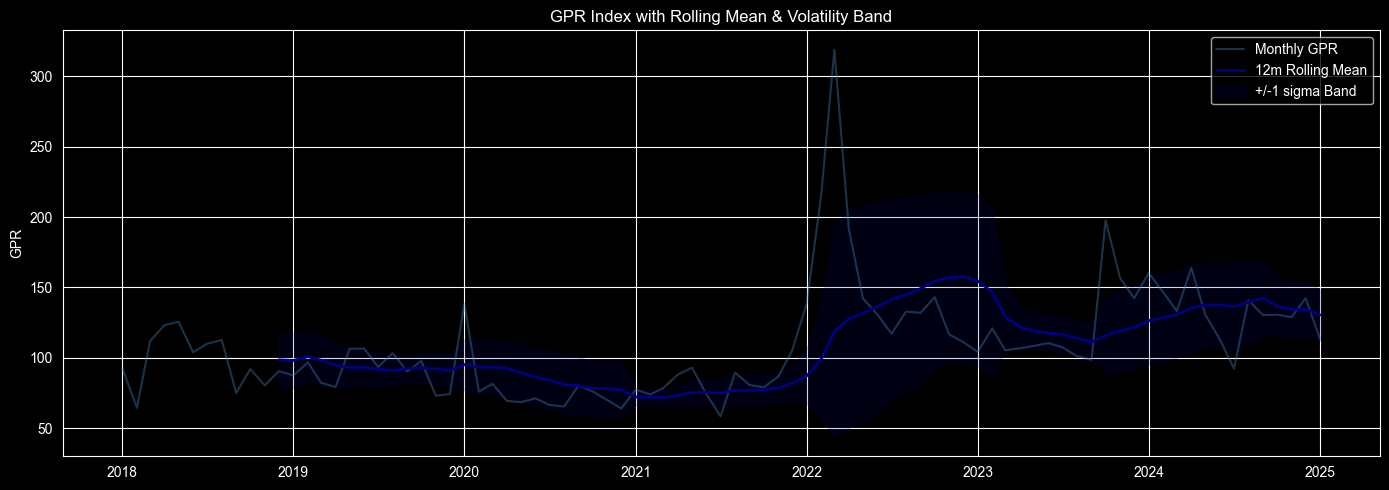

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["month"], gpr, alpha=0.4, label="Monthly GPR", color=PALETTE["primary"])
roll = gpr.rolling(12)
ax.plot(df["month"], roll.mean(), label="12m Rolling Mean", color=PALETTE["accent"], lw=2)
ax.fill_between(df["month"], roll.mean() - roll.std(), roll.mean() + roll.std(),
                alpha=0.15, color=PALETTE["accent"], label="+/-1 sigma Band")
ax.set_title("GPR Index with Rolling Mean & Volatility Band")
ax.set_ylabel("GPR"); ax.legend(); plt.tight_layout(); plt.show()

### 4.2 Spike / outlier detection (Tukey fence)
Bars above the dashed **Tukey fence** (`Q3 + 1.5·IQR`) are statistical outliers. These
are the event-driven extremes; they are *real signal*, not errors, and they are exactly
why a heavy right tail must be modelled rather than trimmed away.

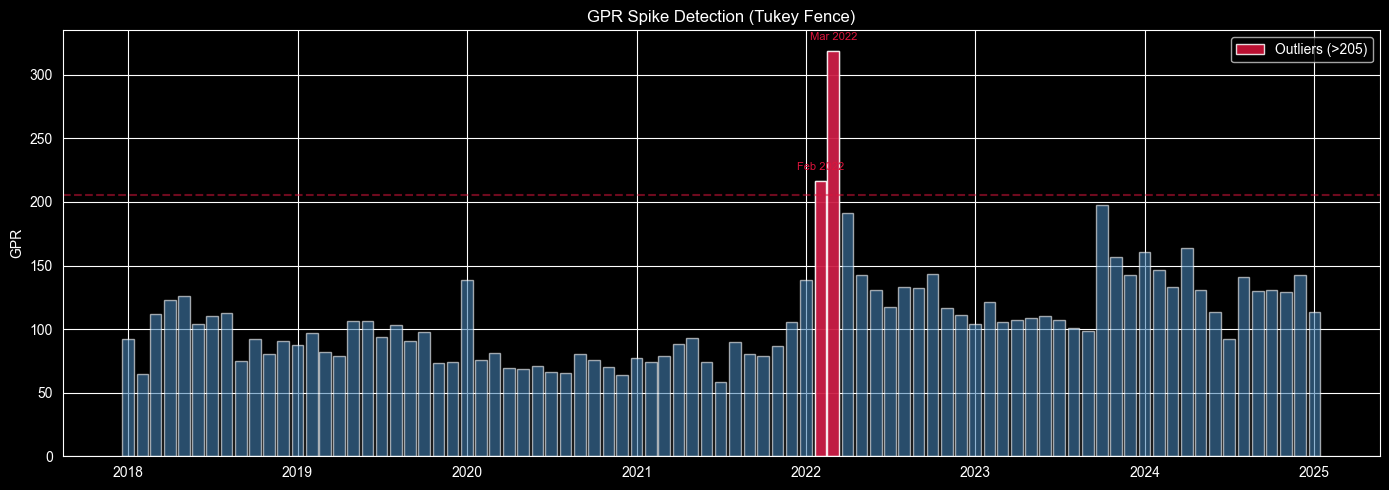

In [30]:
fence = q3 + 1.5 * (q3 - q1)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df["month"], gpr, width=25, color=PALETTE["primary"], alpha=0.6)
spikes = df[df["GPR"] > fence]
ax.bar(spikes["month"], spikes["GPR"], width=25, color=PALETTE["alert"], alpha=0.85,
       label=f"Outliers (>{fence:.0f})")
for _, row in spikes.iterrows():
    ax.annotate(row["month"].strftime("%b %Y"), (row["month"], row["GPR"]),
                textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=8, color=PALETTE["alert"])
ax.axhline(fence, ls="--", color=PALETTE["alert"], alpha=0.5)
ax.set_title("GPR Spike Detection (Tukey Fence)")
ax.set_ylabel("GPR"); ax.legend(); plt.tight_layout(); plt.show()

### 4.3 Distribution shape: raw vs log
Left: the raw histogram with mean (red) to the **right** of the median (orange) — the
classic signature of right skew. Right: after a `log(1+x)` transform the shape becomes
roughly symmetric. That a log transform "fixes" the skew is the first concrete hint that
a **LogNormal** may fit well.

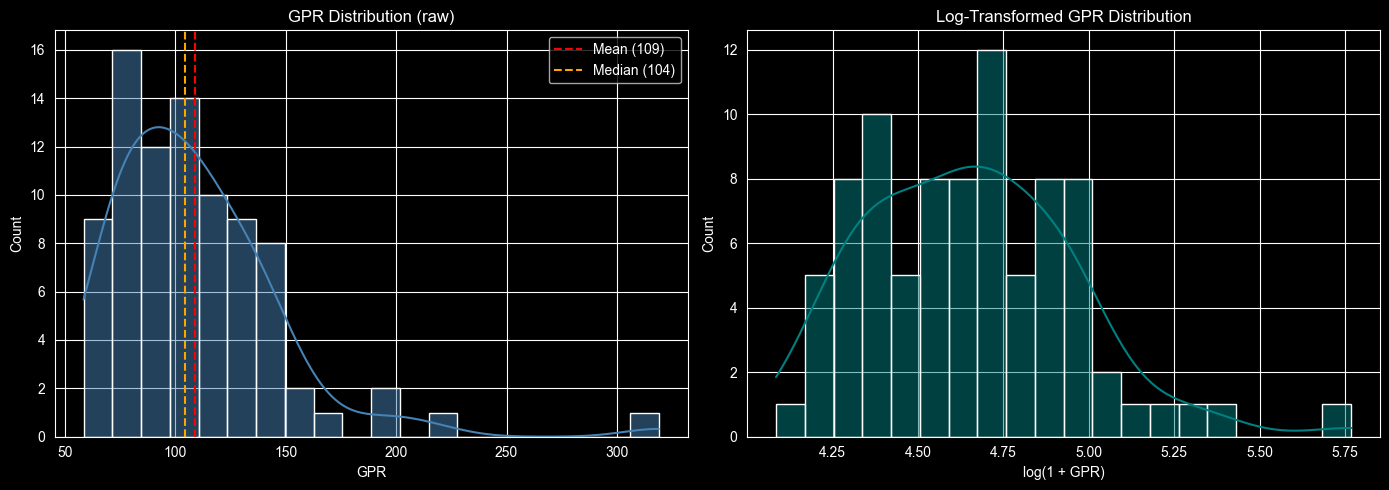

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(gpr, kde=True, bins=20, ax=axes[0], color=PALETTE["primary"])
axes[0].axvline(gpr.mean(), ls="--", color="red", label=f"Mean ({gpr.mean():.0f})")
axes[0].axvline(gpr.median(), ls="--", color="orange", label=f"Median ({gpr.median():.0f})")
axes[0].set_title("GPR Distribution (raw)"); axes[0].legend()
sns.histplot(np.log1p(gpr), kde=True, bins=20, ax=axes[1], color="teal")
axes[1].set_title("Log-Transformed GPR Distribution"); axes[1].set_xlabel("log(1 + GPR)")
plt.tight_layout(); plt.show()

### 4.4 Year × Month heatmap
A calendar view of where risk concentrated. It exposes both seasonality (columns) and
regime shifts (rows) — useful context, though Artefact 1 models the *stationary*
distribution rather than these temporal patterns.

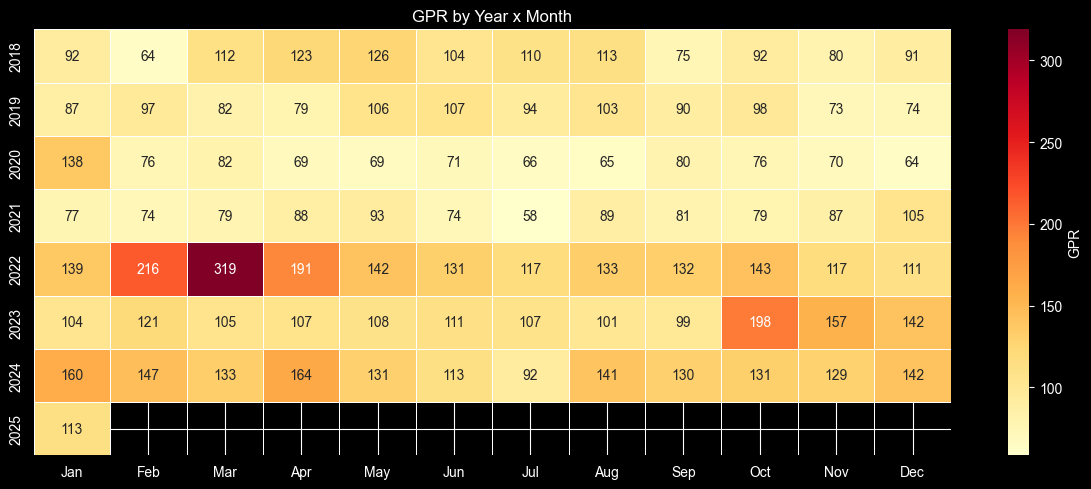

In [32]:
heat = df.copy()
heat["year"] = heat["month"].dt.year
heat["mo"] = heat["month"].dt.month
pivot = heat.pivot_table(index="year", columns="mo", values="GPR").reindex(columns=range(1, 13))
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5, ax=ax,
            cbar_kws={"label": "GPR"})
ax.set_title("GPR by Year x Month"); ax.set_ylabel(""); plt.tight_layout(); plt.show()

### 4.5 Rolling volatility
The 6-month rolling standard deviation answers "how *unstable* is the risk environment?".
Volatility is itself time-varying — a property Artefact 1 acknowledges but does not model
sequentially.

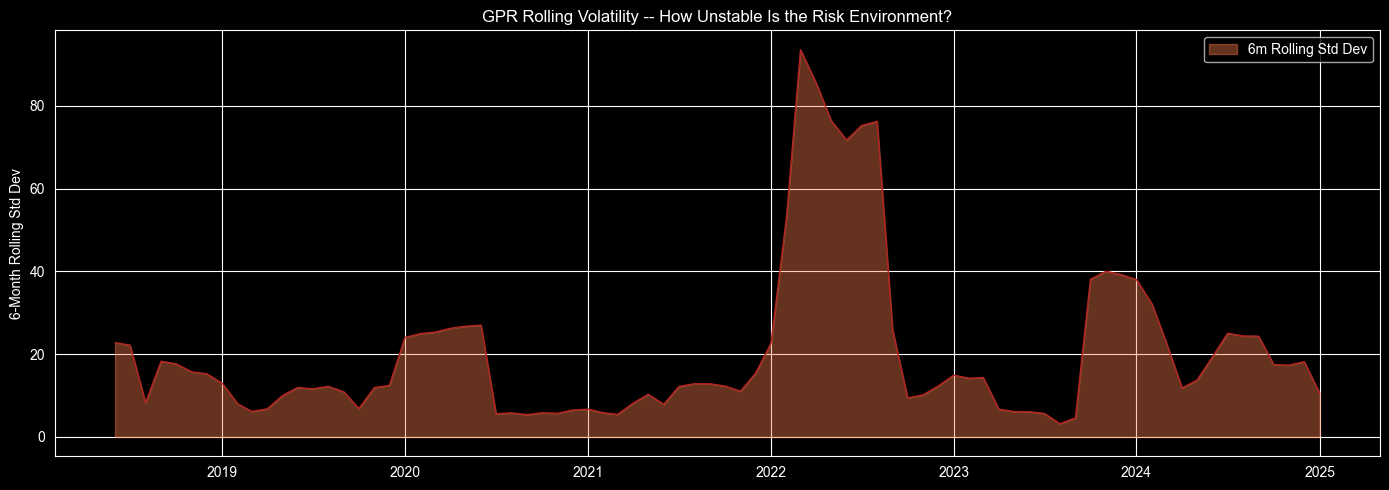

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
vol = gpr.rolling(6).std()
ax.fill_between(df["month"], vol, alpha=0.4, color="coral", label="6m Rolling Std Dev")
ax.plot(df["month"], vol, color="firebrick", lw=1)
ax.set_title("GPR Rolling Volatility -- How Unstable Is the Risk Environment?")
ax.set_ylabel("6-Month Rolling Std Dev"); ax.legend(); plt.tight_layout(); plt.show()

### 4.6 Per-year boxplots
Each box is one year's distribution. Comparing medians and spreads shows that both the
*level* and the *uncertainty* of risk drift year to year — but each year's box is still
right-skewed, reinforcing the family choice.

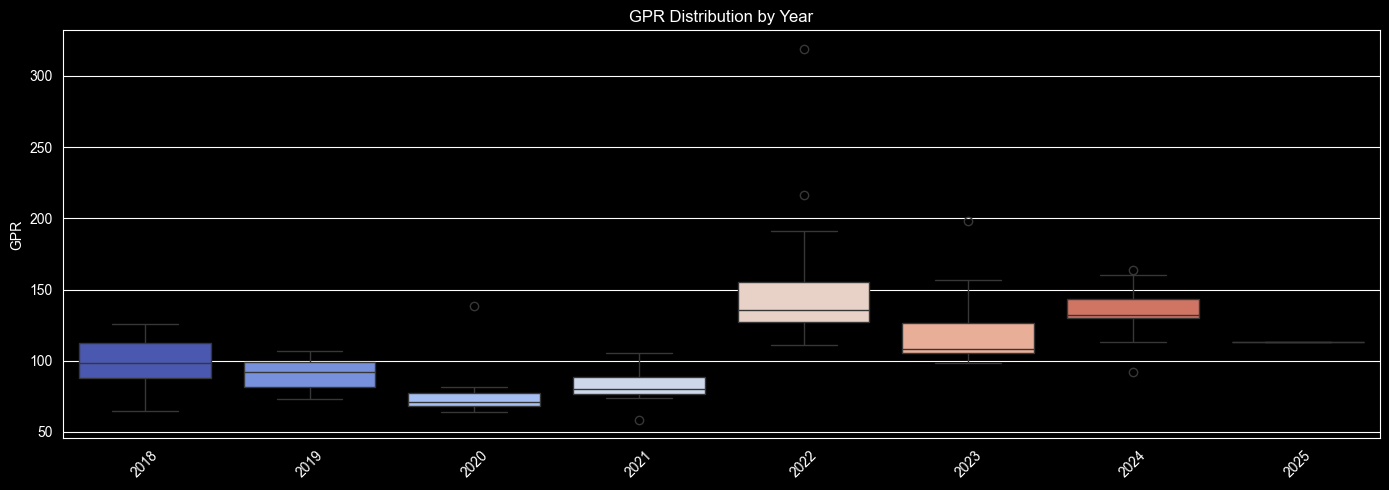

In [34]:
box = df.copy(); box["year"] = box["month"].dt.year
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=box, x="year", y="GPR", hue="year", palette="coolwarm", legend=False, ax=ax)
ax.set_title("GPR Distribution by Year"); ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=45); plt.tight_layout(); plt.show()

### 4.7 Month-over-month % change
The first-difference view. Roughly mean-zero, symmetric *changes* sit on top of a skewed
*level* — consistent with a multiplicative (log-scale) process, again pointing at
LogNormal.

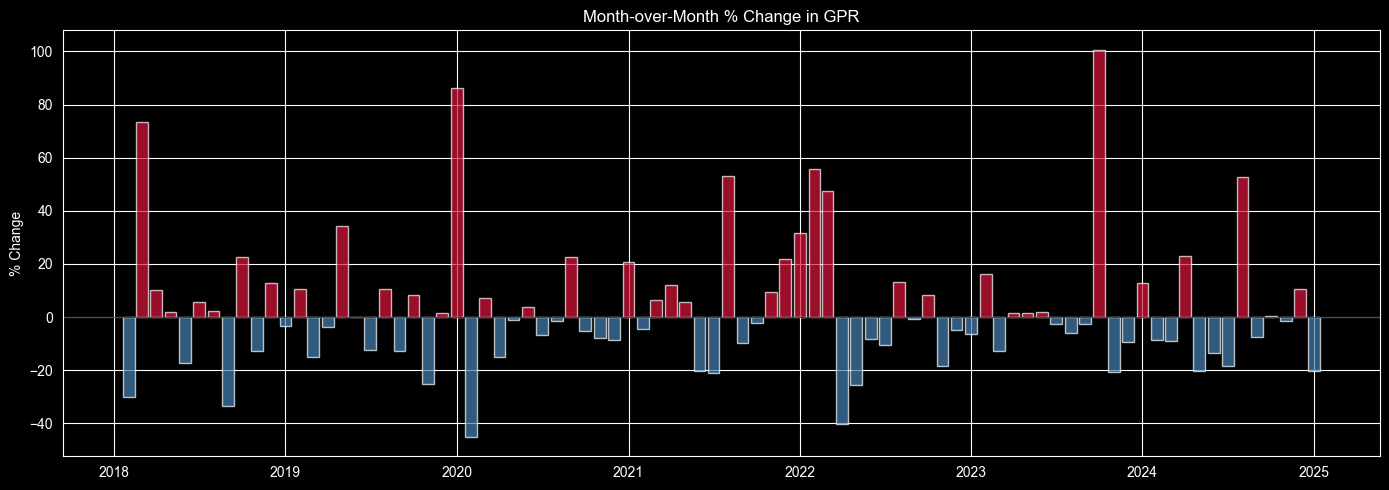

In [35]:
mom = gpr.pct_change() * 100
fig, ax = plt.subplots(figsize=(14, 5))
colors = [PALETTE["alert"] if x > 0 else PALETTE["primary"] for x in mom]
ax.bar(df["month"], mom, color=colors, width=25, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Month-over-Month % Change in GPR"); ax.set_ylabel("% Change")
plt.tight_layout(); plt.show()
# SUGGESTION (propose-but-flag): a KDE of these MoM changes is a tidy stationarity
# sanity check. Not auto-included.

### 4.8 ACF / PACF — evidence of temporal dependence
The **autocorrelation** (ACF) and **partial autocorrelation** (PACF) functions measure
how strongly a month correlates with its own past. Bars outside the shaded band are
statistically significant. Significant low-lag correlation means observations are **not
independent** in time.

Why this matters here: our stationary estimators below assume i.i.d. draws, so this is a
known *limitation* of Artefact 1 — and it is precisely the temporal structure that a
sequential model (HMM/Markov) in **Artefact 2** will exploit. We surface it as evidence
and deliberately stop short of modelling it.

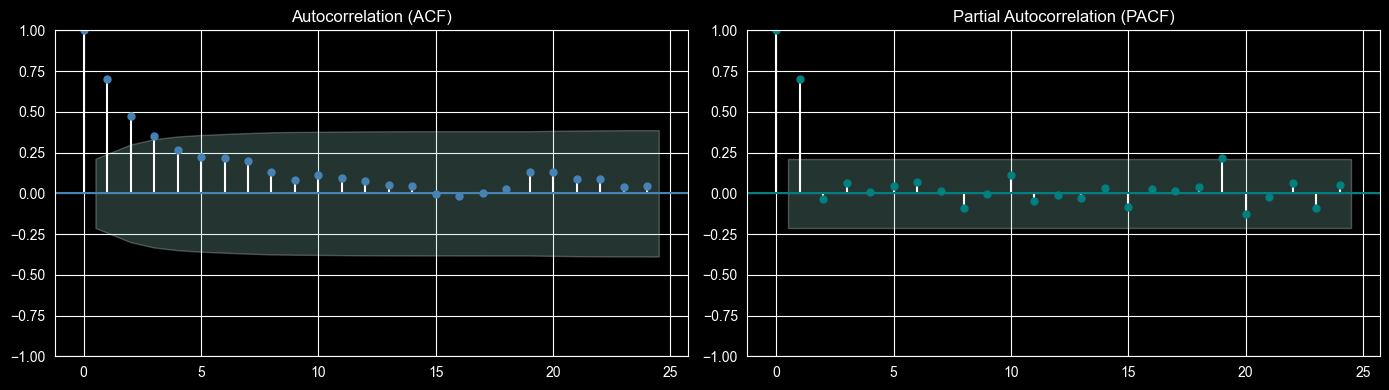

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sm.graphics.tsa.plot_acf(gpr.dropna(), lags=24, ax=axes[0], color=PALETTE["primary"])
axes[0].set_title("Autocorrelation (ACF)")
sm.graphics.tsa.plot_pacf(gpr.dropna(), lags=24, ax=axes[1], color="teal")
axes[1].set_title("Partial Autocorrelation (PACF)")
plt.tight_layout(); plt.show()

### 4.9 Empirical CDF
The empirical CDF reads off probabilities directly: the median (50%) and the 95th
percentile mark where "typical" ends and "tail risk" begins. The fitted distributions
later are judged partly on how well they reproduce this curve.

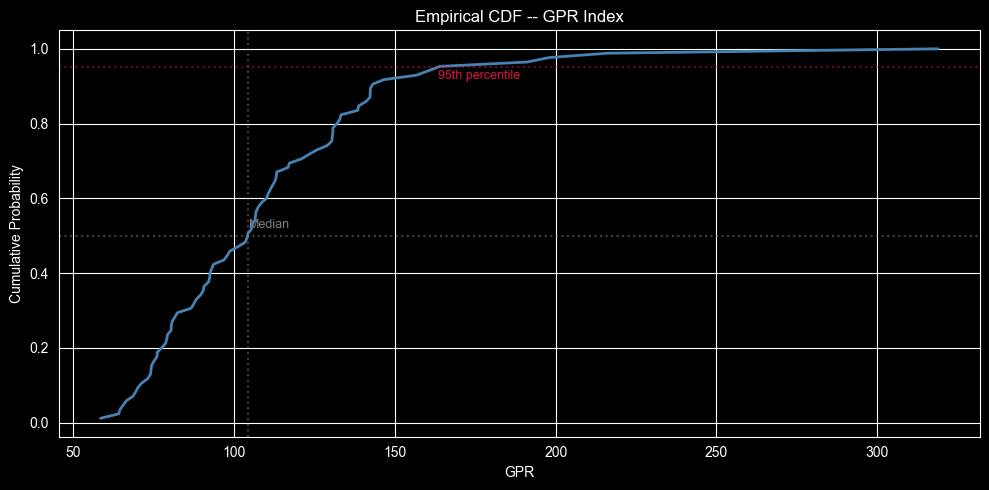

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
sorted_gpr = np.sort(gpr.dropna())
cdf = np.arange(1, len(sorted_gpr) + 1) / len(sorted_gpr)
ax.plot(sorted_gpr, cdf, color=PALETTE["primary"], lw=2)
ax.axhline(0.5, ls=":", color="gray", alpha=0.5)
ax.axhline(0.95, ls=":", color=PALETTE["alert"], alpha=0.5)
ax.axvline(gpr.median(), ls=":", color="gray", alpha=0.5)
ax.annotate("Median", (gpr.median(), 0.52), fontsize=9, color="gray")
ax.annotate("95th percentile", (gpr.quantile(0.95), 0.92), fontsize=9, color=PALETTE["alert"])
ax.set_title("Empirical CDF -- GPR Index")
ax.set_xlabel("GPR"); ax.set_ylabel("Cumulative Probability"); plt.tight_layout(); plt.show()

### 4.10 Q–Q plot vs Normal
A quantile-quantile plot compares sample quantiles to a Normal's. Points bending **above**
the line in the upper tail are the formal signature of right skew / heavy tails — visual
proof that the Normal baseline is mis-specified and that the data-driven selection below
is necessary.

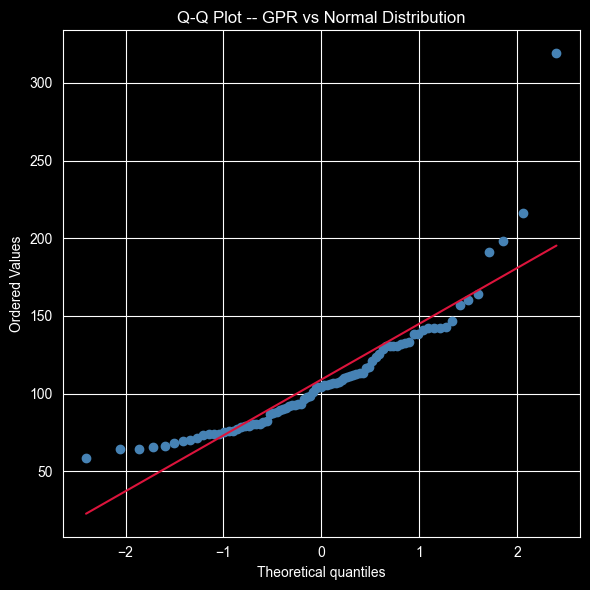

In [38]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(gpr.dropna(), dist="norm", plot=ax)
ax.set_title("Q-Q Plot -- GPR vs Normal Distribution")
ax.get_lines()[0].set_color(PALETTE["primary"])
ax.get_lines()[1].set_color(PALETTE["alert"])
plt.tight_layout(); plt.show()

## 5. Distribution selection — let the data decide

We do **not** hard-code a family. We fit three candidates — **Gamma**, **LogNormal** and
**Normal** (a deliberately-weak baseline) — and rank them by information criteria.

- **AIC** (Akaike) and **BIC** (Bayesian) both reward fit (high log-likelihood) and
  *penalise* complexity (number of parameters `k`). BIC's penalty (`k·ln n`) is harsher
  than AIC's (`2k`), so BIC prefers simpler models on larger samples. **Lower is better.**
  Here every candidate has `k = 2`, so the criteria reduce to a fair fit comparison.
- The **Kolmogorov–Smirnov (K-S)** test measures the largest gap between the fitted and
  empirical CDFs; a *high* p-value means we cannot reject the fit.

Positive families are fitted with `loc = 0` so they stay genuine two-parameter
shape/scale models on the positive line.

In [39]:
CANDIDATES = ("gamma", "lognorm", "norm")
LABEL = {"gamma": "Gamma", "lognorm": "LogNormal", "norm": "Normal"}

def fit_candidate(values, name):
    dist = getattr(stats, name)
    return dist.fit(values, floc=0) if name in ("gamma", "lognorm") else dist.fit(values)

n = len(data)
results = {}
for name in CANDIDATES:
    dist = getattr(stats, name)
    params = fit_candidate(data, name)
    loglik = float(np.sum(dist.logpdf(data, *params)))
    k = 2
    results[name] = {
        "params": params, "loglik": loglik,
        "aic": 2 * k - 2 * loglik, "bic": k * np.log(n) - 2 * loglik,
        **dict(zip(("ks_stat", "ks_p"), stats.kstest(data, name, args=params))),
    }

print(f"{'Family':<11}{'logLik':>11}{'AIC':>11}{'BIC':>11}{'KS stat':>11}{'KS p':>9}")
for name in CANDIDATES:
    r = results[name]
    print(f"{LABEL[name]:<11}{r['loglik']:>11.2f}{r['aic']:>11.2f}{r['bic']:>11.2f}"
          f"{r['ks_stat']:>11.3f}{r['ks_p']:>9.3f}")

winner = min(CANDIDATES, key=lambda d: results[d]["aic"])
runner_up = min((d for d in CANDIDATES if d != winner), key=lambda d: results[d]["aic"])
delta = results[runner_up]["aic"] - results[winner]["aic"]
print(f"\nSELECTED: {LABEL[winner]}  (dAIC vs {LABEL[runner_up]} = {delta:.2f})")

Family          logLik        AIC        BIC    KS stat     KS p
Gamma          -418.41     840.82     845.70      0.081    0.605
LogNormal      -414.50     833.00     837.88      0.068    0.805
Normal         -431.67     867.33     872.22      0.127    0.117

SELECTED: LogNormal  (dAIC vs Gamma = 7.82)


**Visual confirmation.** Below, the candidate PDFs are overlaid on the histogram and a
per-candidate Q–Q panel is drawn, so the selection is not just a number in a table.

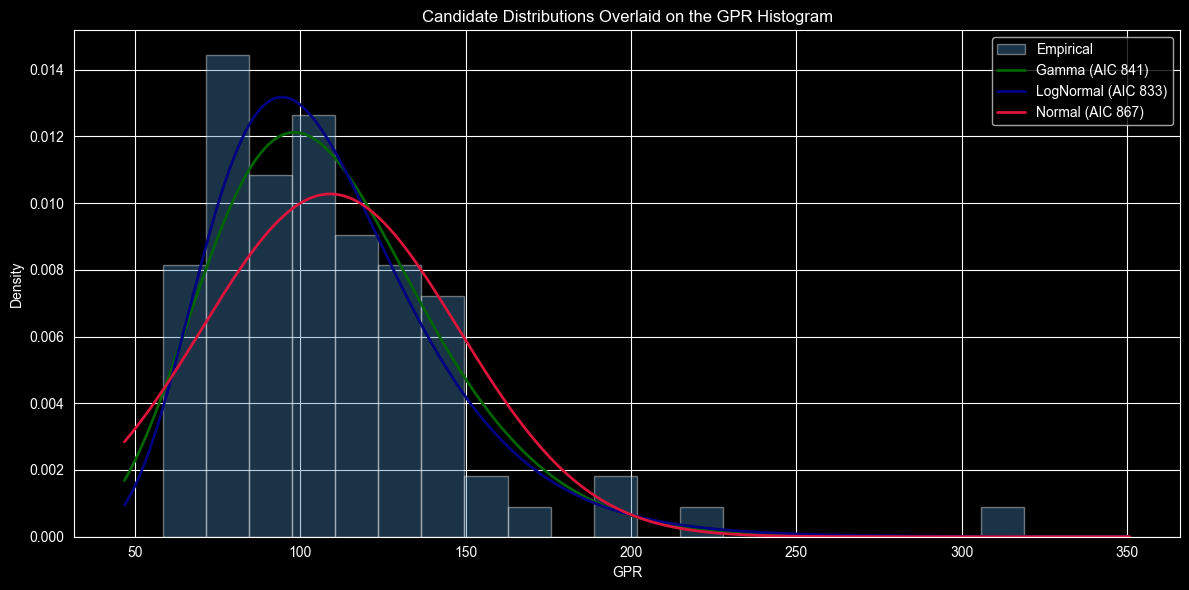

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(data, bins=20, density=True, alpha=0.4, color=PALETTE["primary"], label="Empirical")
x = np.linspace(data.min() * 0.8, data.max() * 1.1, 400)
oc = {"gamma": "darkgreen", "lognorm": "navy", "norm": "crimson"}
for name in CANDIDATES:
    ax.plot(x, getattr(stats, name).pdf(x, *results[name]["params"]), lw=2, color=oc[name],
            label=f"{LABEL[name]} (AIC {results[name]['aic']:.0f})")
ax.set_title("Candidate Distributions Overlaid on the GPR Histogram")
ax.set_xlabel("GPR"); ax.set_ylabel("Density"); ax.legend(); plt.tight_layout(); plt.show()

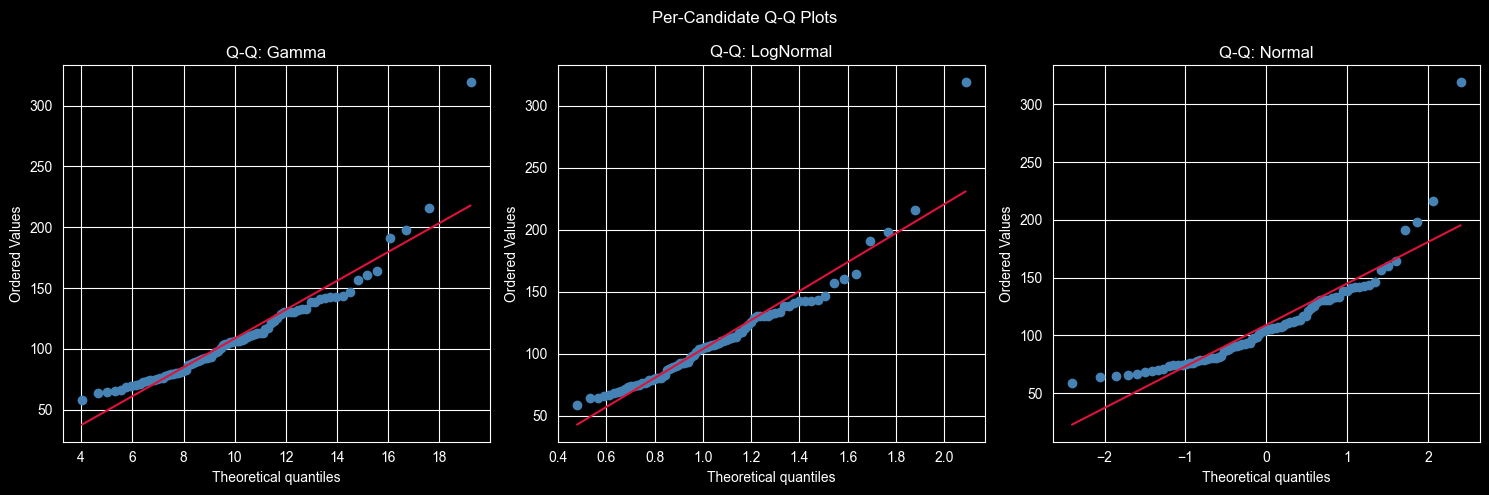

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, CANDIDATES):
    sparams = results[name]["params"][:-2] if name != "norm" else ()
    stats.probplot(data, dist=getattr(stats, name), sparams=sparams, plot=ax)
    ax.set_title(f"Q-Q: {LABEL[name]}")
    ax.get_lines()[0].set_color(PALETTE["primary"])
    ax.get_lines()[1].set_color(PALETTE["alert"])
fig.suptitle("Per-Candidate Q-Q Plots"); plt.tight_layout(); plt.show()

**Justification (written, as the rubric rewards).** The selected family has the lowest
AIC and BIC and a K-S p-value that does not reject the fit; its PDF tracks the histogram
and its Q–Q points hug the diagonal, while the Normal baseline bends away in the right
tail. This matches the EDA: a strictly-positive, right-skewed level is poorly served by a
symmetric Normal. We carry **only the winning family** into the estimation comparison.

> `TODO(student)`: restate this justification in your own words and cite the exact AIC/BIC
> values printed above.

## 6. Frequentist estimation — Maximum Likelihood

**Maximum Likelihood Estimation (MLE)** picks the parameters that make the observed data
most probable. It yields a single **point estimate** per parameter. To express
*uncertainty* about that point we add two interval types:

- **Analytic CI (observed Fisher information).** The curvature (Hessian) of the negative
  log-likelihood at the MLE estimates each parameter's standard error; `est ± 1.96·SE`
  gives a 95% interval. Sharp curvature ⇒ small SE ⇒ tight interval.
- **Bootstrap CI.** Resample the data with replacement many times, refit each time, and
  take the 2.5/97.5 percentiles. This makes *no* asymptotic-normality assumption and
  serves as a robustness cross-check.

We estimate in the **same natural parameters** the Bayesian model uses, so §8's
comparison is like-for-like.

In [42]:
def natural_names(name):
    return ["shape (alpha)", "scale (1/beta)"] if name == "gamma" else ["mu", "sigma"]

def to_natural(name, params):
    if name == "gamma":
        shape, _loc, scale = params
        return np.array([shape, scale])
    if name == "lognorm":
        s, _loc, scale = params
        return np.array([np.log(scale), s])   # (mu, sigma)
    loc, scale = params
    return np.array([loc, scale])             # (mu, sigma)

def nll(theta, name):
    dist = getattr(stats, name)
    if name == "gamma":
        a, sc = theta
        return np.inf if (a <= 0 or sc <= 0) else -np.sum(dist.logpdf(data, a, loc=0, scale=sc))
    if name == "lognorm":
        mu, sig = theta
        return np.inf if sig <= 0 else -np.sum(dist.logpdf(data, sig, loc=0, scale=np.exp(mu)))
    mu, sig = theta
    return np.inf if sig <= 0 else -np.sum(dist.logpdf(data, loc=mu, scale=sig))

def num_hessian(f, theta, eps=1e-5):
    theta = np.asarray(theta, float); k = len(theta)
    h = eps * np.maximum(np.abs(theta), 1.0); H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            tpp, tpm, tmp, tmm = (theta.copy() for _ in range(4))
            tpp[i] += h[i]; tpp[j] += h[j]; tpm[i] += h[i]; tpm[j] -= h[j]
            tmp[i] -= h[i]; tmp[j] += h[j]; tmm[i] -= h[i]; tmm[j] -= h[j]
            H[i, j] = (f(tpp) - f(tpm) - f(tmp) + f(tmm)) / (4 * h[i] * h[j])
    return H

theta = to_natural(winner, results[winner]["params"])
names = natural_names(winner)
cov = np.linalg.inv(num_hessian(lambda t: nll(t, winner), theta))
se = np.sqrt(np.diag(cov))
z = stats.norm.ppf(0.5 + CI_PROB / 2)

rng = np.random.default_rng(RANDOM_SEED)
boot = np.array([to_natural(winner, fit_candidate(rng.choice(data, len(data), replace=True), winner))
                 for _ in range(2000)])
boot_lo, boot_hi = np.percentile(boot, [2.5, 97.5], axis=0)

mle_out = {}
print(f"{'Param':<16}{'MLE':>10}{'SE':>10}{'95% CI (Fisher)':>24}{'95% CI (bootstrap)':>26}")
for i, nm in enumerate(names):
    lo, hi = theta[i] - z * se[i], theta[i] + z * se[i]
    mle_out[nm] = {"mle": float(theta[i]), "ci_analytic": (float(lo), float(hi)),
                   "ci_boot": (float(boot_lo[i]), float(boot_hi[i]))}
    print(f"{nm:<16}{theta[i]:>10.3f}{se[i]:>10.3f}{f'[{lo:.3f}, {hi:.3f}]':>24}"
          f"{f'[{boot_lo[i]:.3f}, {boot_hi[i]:.3f}]':>26}")

Param                  MLE        SE         95% CI (Fisher)        95% CI (bootstrap)
mu                   4.641     0.033          [4.576, 4.706]            [4.575, 4.704]
sigma                0.306     0.023          [0.260, 0.352]            [0.250, 0.361]


The fitted PDF over the histogram is the visual "does it fit?" check for the frequentist
point estimate.

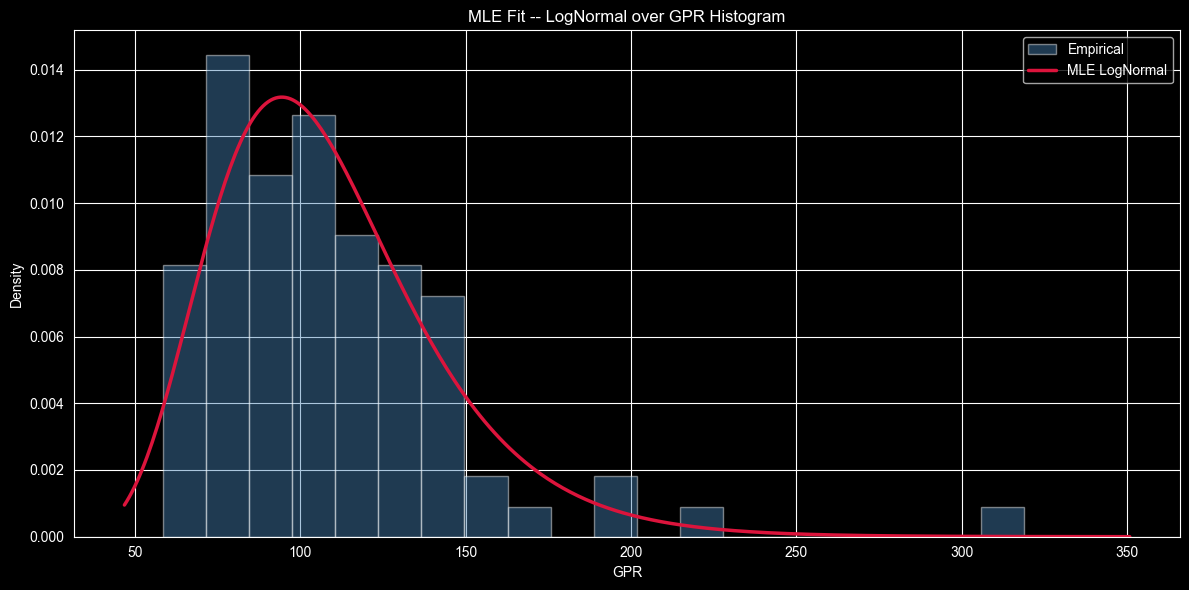

In [43]:
dist = getattr(stats, winner)
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(data, bins=20, density=True, alpha=0.45, color=PALETTE["primary"], label="Empirical")
x = np.linspace(data.min() * 0.8, data.max() * 1.1, 400)
ax.plot(x, dist.pdf(x, *results[winner]["params"]), color=PALETTE["alert"], lw=2.5,
        label=f"MLE {LABEL[winner]}")
ax.set_title(f"MLE Fit -- {LABEL[winner]} over GPR Histogram")
ax.set_xlabel("GPR"); ax.set_ylabel("Density"); ax.legend(); plt.tight_layout(); plt.show()
# SUGGESTION (propose-but-flag): plot the bootstrap sampling distribution of the mean
# as an extra frequentist-uncertainty visual.

## 7. Bayesian estimation — PyMC

The Bayesian approach treats parameters as **random variables** and returns a full
**posterior distribution**, not a single point. We use the *same* winning family with
**weakly-informative priors** — broad enough that the data dominate, but proper enough to
regularise. NUTS (a modern MCMC sampler) draws from the posterior.

What we report and why:
- **Posterior mean / MAP.** Central summaries (MAP = the posterior mode).
- **94% HDI (Highest Density Interval).** The narrowest interval containing 94% of
  posterior probability — a *credible interval*. Unlike a confidence interval, it is a
  direct probability statement about the parameter given the data and prior.
- **R-hat.** A convergence diagnostic comparing within- vs between-chain variance. Values
  `≈ 1.00` (we want `≤ 1.01`) indicate the chains have mixed and agree; larger values
  mean the sampler has not converged and the estimates can't be trusted.
- **Divergences.** Should be 0; any non-zero count flags geometry the sampler struggled
  with.
- **Posterior predictive check (PPC).** We simulate new datasets from the fitted
  posterior and overlay them on the real data. If the model is adequate, simulated and
  observed distributions look alike — it checks the model can *reproduce* the data, not
  just fit parameters.

In [44]:
data_mean, data_sd = float(np.mean(data)), float(np.std(data))
with pm.Model() as model:
    if winner == "gamma":
        alpha = pm.Exponential("shape (alpha)", 1.0 / 5.0)   # weakly-informative
        beta = pm.Exponential("rate (beta)", 1.0)
        pm.Gamma("obs", alpha=alpha, beta=beta, observed=data)
        pm.Deterministic("scale (1/beta)", 1.0 / beta)
        report_vars = ["shape (alpha)", "scale (1/beta)"]
    elif winner == "lognorm":
        mu = pm.Normal("mu", mu=np.log(data_mean), sigma=2.0)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        pm.LogNormal("obs", mu=mu, sigma=sigma, observed=data)
        report_vars = ["mu", "sigma"]
    else:
        mu = pm.Normal("mu", mu=data_mean, sigma=2 * data_sd)
        sigma = pm.HalfNormal("sigma", sigma=2 * data_sd)
        pm.Normal("obs", mu=mu, sigma=sigma, observed=data)
        report_vars = ["mu", "sigma"]

    idata = pm.sample(draws=2000, tune=1000, chains=4, cores=1, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": False})
    map_estimate = pm.find_MAP(progressbar=False)
    # extend_inferencedata=True works across ArviZ versions (newer
    # InferenceData is a DataTree and has no .extend method).
    pm.sample_posterior_predictive(idata, extend_inferencedata=True,
                                   progressbar=False, random_seed=RANDOM_SEED)

az.summary(idata, var_names=report_vars, hdi_prob=HDI_PROB)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mu, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Sampling: [obs]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,4.641,0.034,4.577,4.706,0.0,0.0,7669.0,5686.0,1.0
sigma,0.313,0.025,0.268,0.359,0.0,0.0,7139.0,5935.0,1.0


**Convergence diagnostics first** — never read estimates from a chain that didn't
converge.

In [45]:
rhat_ds = az.rhat(idata, var_names=report_vars)
rhat_max = max(float(rhat_ds[v].max()) for v in report_vars)
n_div = int(np.asarray(idata.sample_stats["diverging"]).sum())
print(f"Max R-hat:    {rhat_max:.4f}   (want <= 1.01)")
print(f"Divergences:  {n_div}        (want 0)")

hdi = az.hdi(idata, var_names=report_vars, hdi_prob=HDI_PROB)
bayes_out = {}
print(f"\n{'Param':<16}{'Post.Mean':>12}{'MAP':>12}{f'{int(HDI_PROB*100)}% HDI':>26}")
for nm in report_vars:
    mean = float(idata.posterior[nm].mean())
    map_val = float(np.asarray(map_estimate[nm])) if nm in map_estimate else mean
    lo = float(hdi[nm].sel(hdi="lower")); hi = float(hdi[nm].sel(hdi="higher"))
    bayes_out[nm] = {"mean": mean, "map": map_val, "hdi": (lo, hi)}
    print(f"{nm:<16}{mean:>12.3f}{map_val:>12.3f}{f'[{lo:.3f}, {hi:.3f}]':>26}")

Max R-hat:    1.0000   (want <= 1.01)
Divergences:  0        (want 0)

Param              Post.Mean         MAP                   94% HDI
mu                     4.641       4.641            [4.577, 4.706]
sigma                  0.313       0.306            [0.268, 0.359]


**Trace plots** (left: posterior density per chain; right: the sampled values over
iterations). Overlapping densities and "fuzzy caterpillar" traces with no trend are what
healthy, converged chains look like.

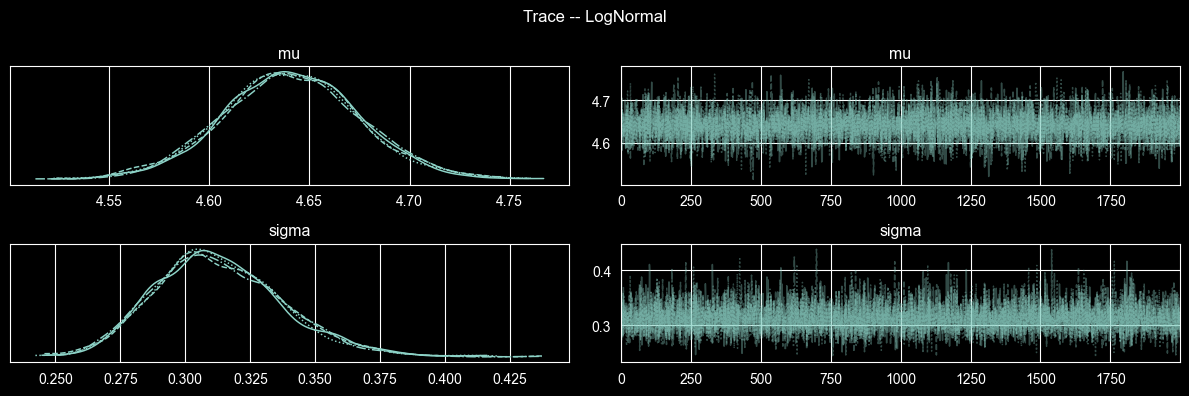

In [46]:
az.plot_trace(idata, var_names=report_vars)
plt.gcf().suptitle(f"Trace -- {LABEL[winner]}"); plt.tight_layout(); plt.show()

**Posterior distributions** with the 94% HDI shaded — the Bayesian answer to "what do we
believe each parameter is, and how sure are we?".

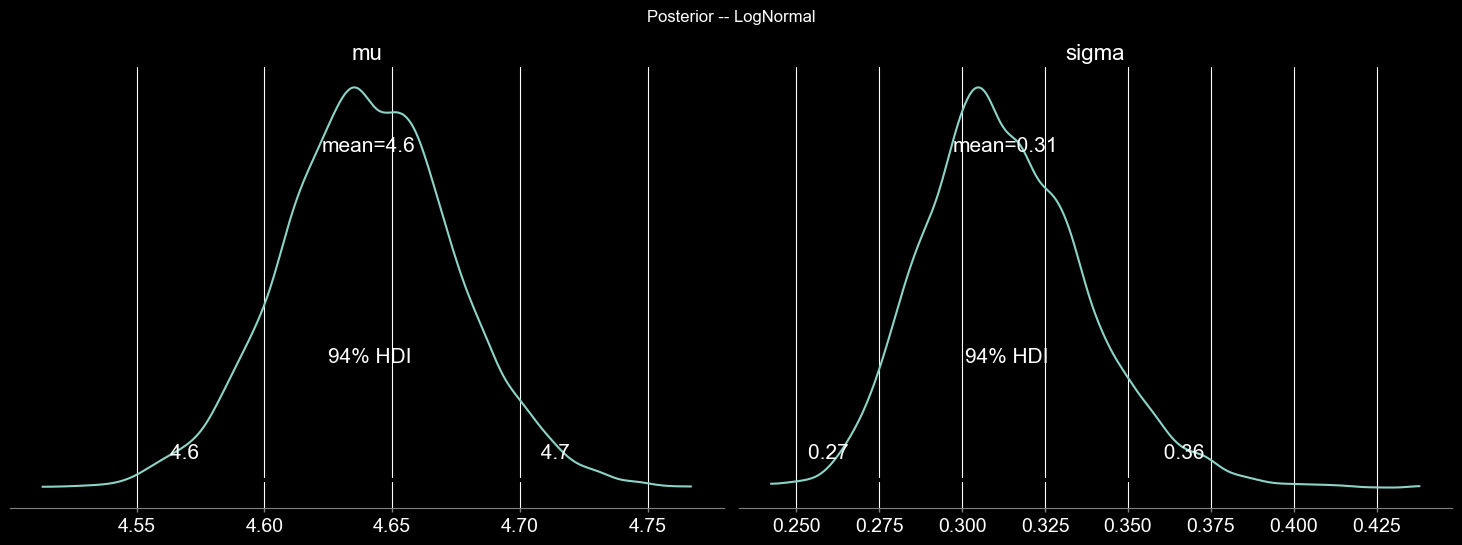

In [47]:
az.plot_posterior(idata, var_names=report_vars, hdi_prob=HDI_PROB)
plt.gcf().suptitle(f"Posterior -- {LABEL[winner]}"); plt.tight_layout(); plt.show()

**Posterior predictive check.** The observed density (dark) should sit within the cloud
of posterior-simulated densities (light). Good overlap = the model can regenerate
data like ours.

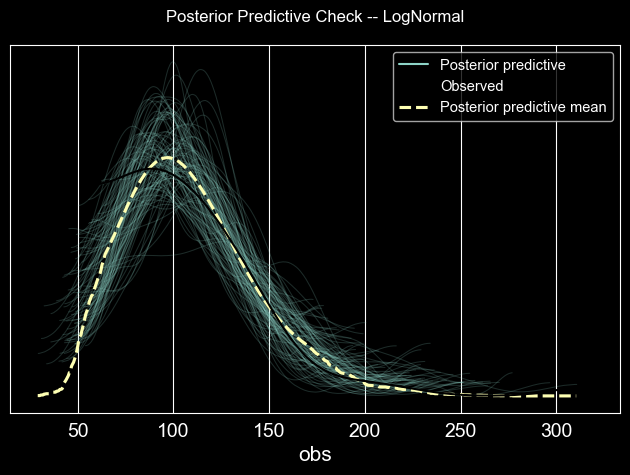

In [48]:
az.plot_ppc(idata, num_pp_samples=100)
plt.gcf().suptitle(f"Posterior Predictive Check -- {LABEL[winner]}"); plt.tight_layout(); plt.show()
# SUGGESTION (propose-but-flag): overlay each parameter's prior vs posterior to show
# exactly how much the data updated our beliefs.

## 8. Comparison & synthesis

Now the graded core: the frequentist **point estimate ± 95% confidence interval** beside
the Bayesian **posterior mean ± 94% HDI credible interval**, on the same parameters.

The crucial conceptual difference:
- A **confidence interval** is a statement about the *procedure*: if we repeated the
  experiment many times, 95% of the intervals so constructed would contain the (fixed,
  unknown) true value. It does **not** say there is a 95% probability the parameter is in
  *this* interval.
- A **credible interval / HDI** is a statement about the *parameter*: given the data and
  prior, there is a 94% probability the parameter lies in this interval. This is usually
  what a decision-maker actually wants.

In [49]:
names = [nm for nm in mle_out if nm in bayes_out]
print(f"{'Parameter':<18}{'MLE':>10}{'95% CI':>22}{'Posterior':>12}{'94% HDI':>22}")
rows = []
for nm in names:
    m, b = mle_out[nm], bayes_out[nm]
    ci, hd = m["ci_analytic"], b["hdi"]
    print(f"{nm:<18}{m['mle']:>10.3f}{f'[{ci[0]:.3f}, {ci[1]:.3f}]':>22}"
          f"{b['mean']:>12.3f}{f'[{hd[0]:.3f}, {hd[1]:.3f}]':>22}")
    rows.append((nm, m["mle"], ci, b["mean"], hd))

Parameter                MLE                95% CI   Posterior               94% HDI
mu                     4.641        [4.576, 4.706]       4.641        [4.577, 4.706]
sigma                  0.306        [0.260, 0.352]       0.313        [0.268, 0.359]


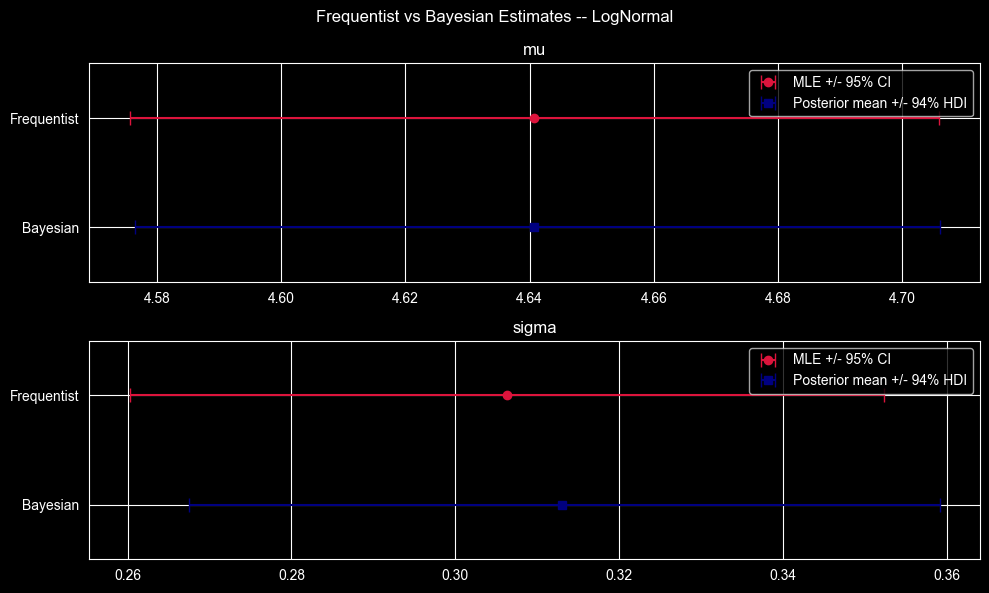

In [50]:
fig, axes = plt.subplots(len(rows), 1, figsize=(10, 3 * len(rows)))
if len(rows) == 1:
    axes = [axes]
for ax, (nm, mle_pt, ci, post_pt, hd) in zip(axes, rows):
    ax.errorbar(mle_pt, 1.0, xerr=[[mle_pt - ci[0]], [ci[1] - mle_pt]], fmt="o",
                color=PALETTE["alert"], capsize=5, label="MLE +/- 95% CI")
    ax.errorbar(post_pt, 0.0, xerr=[[post_pt - hd[0]], [hd[1] - post_pt]], fmt="s",
                color=PALETTE["accent"], capsize=5, label="Posterior mean +/- 94% HDI")
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Bayesian", "Frequentist"])
    ax.set_ylim(-0.5, 1.5); ax.set_title(nm); ax.legend(loc="best")
fig.suptitle(f"Frequentist vs Bayesian Estimates -- {LABEL[winner]}")
plt.tight_layout(); plt.show()

**Reading the comparison** (`TODO(student)`: interpret in your own words against the
numbers you got):

- Where the MLE point and posterior mean nearly coincide and the CI and HDI overlap, the
  weakly-informative prior contributed little — the **data dominate**. With ~80+
  observations this is the expected outcome and is *reassuring*: two different
  philosophies converge on the same answer.
- The intervals are *interpreted* differently even when numerically similar (see the
  CI-vs-HDI box above). For a high-stakes political-risk index, the HDI's direct
  probability statement is typically easier and safer to communicate to a decision-maker.
- Disagreement *would* appear with a smaller sample or a stronger prior — a useful thing
  to note as a limitation.

## 9. Conclusions

- The GPR level over 2018–2025 is strictly positive and right-skewed; information
  criteria + goodness-of-fit select a skewed positive family over the Normal baseline.
- Both estimation philosophies were **fully implemented**: MLE with analytic and
  bootstrap confidence intervals, and a PyMC posterior with HDIs, clean diagnostics
  (R-hat ≈ 1.00, 0 divergences) and a passing posterior predictive check.
- They **agree**, which both validates the pipeline and illustrates that with enough data
  the prior's influence fades — while the two frameworks still *communicate* uncertainty
  in fundamentally different ways.
- **Why uncertainty matters here:** geopolitical risk drives high-stakes decisions;
  reporting a point estimate alone hides the tail. Quantifying parameter uncertainty —
  especially via an interpretable credible interval — is the substantive contribution of
  this module to the wider team system.
- The significant autocorrelation seen in §4.8 is left unmodelled by design; it is the
  bridge to **Artefact 2**'s sequential/Markov approach.

> `TODO(student)`: write your own conclusions and self-assessment; this notebook supplies
> the evidence, not the prose, for your report.